# Step 4b: Modular PieceLog — Independent Sub-Model Training

This notebook trains 3 specialized sub-models for piece-log prediction:
- **TimingModel**: predicts `t_lag` (delay→growth transition)
- **GrowthModel**: predicts `K, r, t0, lam` (growth-phase logistic)
- **DeclineModel**: predicts `t_break, slope, decline_gate` (optional decline)

Each sub-model has its own PatchTST encoder, trained sequentially with phase-specific loss windows.
An optional Phase B fine-tunes all sub-models jointly via CompositeModel.

**Motivation:** The joint PieceLogPatchTST couples all 7 params through a single encoder,
making it hard to learn growth-phase params (K, r, t0, lam — high CV) without overfitting.

In [ ]:
import sys
sys.path.insert(0, "..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from pathlib import Path

from src.data_loader import load_batches
from src.domain_splits import get_control_mode_split
from src.piecelog_model import (
    piecelog_numpy, fit_all_batches, PARAM_NAMES,
)
from src.piecelog_dataset import create_piecelog_dataloaders, compute_param_stats
from src.modular_piecelog import (
    create_modular_piecelog,
    initialize_timing_head,
    initialize_growth_head,
    initialize_decline_head,
)
from src.train_modular_piecelog import (
    train_modular_pipeline,
    train_timing_model,
    train_growth_model,
    train_decline_model,
    train_composite_finetune,
    retrain_timing,
    retrain_growth,
    retrain_decline,
    retrain_split_decline,
    retrain_ungated_decline,
)
from src.train_piecelog import evaluate_piecelog

device = torch.device('cuda' if torch.cuda.is_available() else 'mps' if torch.backends.mps.is_available() else 'cpu')
print(f'Using device: {device}')

## 1. Load Data & Domain Split

In [2]:
batches = load_batches()
split = get_control_mode_split("1c")

source_ids = split["source"]  # Batches 1-60 (recipe + operator)
target_ids = split["target"]  # Batches 61-90 (APC)

print(f"Source batches: {len(source_ids)}")
print(f"Target batches: {len(target_ids)}")

Source batches: 60
Target batches: 30


## 2. Pre-Fit Piece-Log Parameters

In [3]:
# Load cached params if available, else fit
output_dir = Path("../outputs")
params_path = output_dir / "fitted_piecelog_params.csv"

if params_path.exists():
    fitted_params_df = pd.read_csv(params_path)
    print(f"Loaded cached fits: {len(fitted_params_df)} batches")
else:
    fitted_params_df = fit_all_batches(batches, exclude_faults=True)
    output_dir.mkdir(exist_ok=True)
    fitted_params_df.to_csv(params_path, index=False)
    print(f"Fitted {len(fitted_params_df)} batches")

print(f"R² mean: {fitted_params_df['r_squared'].mean():.6f}")
fitted_params_df.describe()

Loaded cached fits: 90 batches
R² mean: 0.999647


,batch_id,K,r,t0,lam,t_lag,t_break,slope,r_squared
count,90.000000,90.000000,90.000000,9.000000e+01,90.000000,90.000000,90.000000,9.000000e+01,90.000000
mean,45.500000,37.064513,0.021367,3.789035e+01,0.022920,25.834098,196.479953,4.826353e-02,0.999647
std,26.124701,9.024119,0.009317,4.099052e+01,0.022882,1.688916,30.283830,6.443983e-02,0.000423
min,1.000000,13.885244,0.004958,4.752243e-36,0.004703,21.713797,126.000000,6.042484e-66,0.996718
25%,23.250000,31.716960,0.015228,5.145676e-06,0.008558,24.684612,178.688209,2.240253e-29,0.999641
50%,45.500000,36.168814,0.019855,2.196138e+01,0.011652,26.004490,206.376363,2.140086e-12,0.999751
75%,67.750000,40.095541,0.026801,7.221985e+01,0.031615,26.964077,215.401385,1.098574e-01,0.999854
max,90.000000,83.800048,0.054360,2.300000e+02,0.129343,29.448737,290.000000,1.969917e-01,0.999939


### 2.1 Parameter Variability — Motivation for Modular Approach

In [4]:
# Show CV per parameter to motivate decomposition
print("Parameter coefficient of variation (CV):")
print("=" * 40)
for name in PARAM_NAMES:
    mean = fitted_params_df[name].mean()
    std = fitted_params_df[name].std()
    cv = std / mean * 100 if mean > 0 else float('inf')
    print(f"  {name:>8s}: mean={mean:10.4f}  std={std:8.4f}  CV={cv:6.1f}%")
print()
print("t_lag has lowest CV (~6.5%) → easiest to predict independently")
print("K, r, t0, lam have high CV → benefit from focused training")

Parameter coefficient of variation (CV):
         K: mean=   37.0645  std=  9.0241  CV=  24.3%
         r: mean=    0.0214  std=  0.0093  CV=  43.6%
        t0: mean=   37.8903  std= 40.9905  CV= 108.2%
       lam: mean=    0.0229  std=  0.0229  CV=  99.8%
     t_lag: mean=   25.8341  std=  1.6889  CV=   6.5%
   t_break: mean=  196.4800  std= 30.2838  CV=  15.4%
     slope: mean=    0.0483  std=  0.0644  CV= 133.5%

t_lag has lowest CV (~6.5%) → easiest to predict independently
K, r, t0, lam have high CV → benefit from focused training


### 3.1 Training Pipeline — Data Flow, Loss Functions, and Scale Analysis

This section documents the complete modular training pipeline for reference.

---

#### Data Pipeline

**Domain split (split "1c"):**
- Source: 60 batches (IDs 1-60, recipe + operator control) &rarr; 80/20 split &rarr; **48 train, 12 val**
- Target: 30 batches (IDs 61-90, APC/Raman control)

**Sampling:** 5 `(T, D)` samples per batch &rarr; **240 train, 60 val, 150 target** samples total.

**Per-sample structure returned by `PieceLogDataset.__getitem__`:**

| Key | Shape | Description |
|-----|-------|-------------|
| `x` | `(500, 28)` | Input time-series: 25 process signals + 3 concentration channels (ffill, mask, time_since), zero-padded or truncated to `max_seq_len=500` |
| `params_fitted` | `(7,)` | Pre-fitted piece-log parameters `[K, r, t0, lam, t_lag, t_break, slope]` |
| `t_predict` | scalar | Absolute prediction time `T + D` (hours) |
| `t_cutoff` | scalar | Absolute time at end of input window (hours) |
| `y_conc` | scalar | True penicillin concentration `P(T+D)` (g/L) |
| `domain_label` | scalar | 0 = source, 1 = target |

**DataLoader batching (batch_size=16):**
Each mini-batch stacks these into `x: (16, 500, 28)`, `params_fitted: (16, 7)`, etc.

**Sampling window:** `min_T_fraction=0.90, max_T_fraction=0.95` (90-95% of batch used as input), `min_D_hours=0.0, max_D_hours=20.0` (short-horizon prediction).

**Augmentation (train only):** Gaussian noise on input signals (`std=0.001`) and multiplicative noise on fitted parameters (`std=0.001`), with re-computation of `y_conc` from perturbed params.

**Normalization:**
- Process signals: z-scored per-feature using training-set statistics
- Concentration channels: z-scored using training-set concentration statistics
- `conc_scale = 9.91 g/L` (concentration std, used to normalize curve losses)
- `param_stats`: per-parameter mean/std from training batches, used to z-score t_lag and growth params

---

#### Loss Function Architecture

All sub-models use a **dual loss**: `L_total = L_curve + alpha * L_param`, where `alpha=0.001`.

**L_curve** evaluates the piecelog function on a **jittered time grid** (`n_curve_points=10`) within a phase-specific window, computes MSE between predicted and true curves, and divides by `conc_scale` to normalize concentration values.

**L_param** normalizes parameters without dataset-specific stats where possible:
- `t_lag`, growth params (`K, r, t0, lam`): z-scored using `param_stats`
- `t_break`: divided by `T_max` (range-normalized, dataset-independent)
- `slope`: log-space MSE on declining batches only (scale-invariant, dataset-independent)

The key design: each sub-model only varies its own predicted parameters; all other parameters are held at their **true fitted values** (for upstream params not yet trained) or **frozen model outputs** (for upstream params from already-trained models).

---

#### Phase A-1: TimingModel (predicts `t_lag`)

```
Loss = L_curve([0, t_lag_true + 0.1*T_max]) + alpha * L_param(t_lag)
```

- **Curve window:** `[0, t_lag_true + 29h]` — the lag/delay region where `P(t) ~ 0`
- **Params varied:** only `t_lag` (predicted); K, r, t0, lam, t_break, slope = true fitted values
- **L_param:** MSE of z-scored `t_lag`
- **Typical loss scale: ~0.001** — very small because the piecelog curve is nearly zero throughout the lag window, so even wrong `t_lag` predictions produce small curve MSE after dividing by `conc_scale`

#### Phase A-2: GrowthModel (predicts `K, r, t0, lam`)

```
Loss = L_curve([t_lag_pred, t_break_true]) + alpha * L_param(K, r, t0, lam)
```

- **Curve window:** `[t_lag_pred, t_break_true]` — the growth region where `P(t)` rises from 0 to K (~37 g/L)
- **t_lag_pred:** from **frozen TimingModel** (no gradient flow back)
- **Params varied:** K, r, t0, lam (predicted); t_break, slope = true fitted values
- **L_param:** mean of z-scored MSE for K, r, t0, lam (4 terms averaged)
- **Typical loss scale: ~0.01-0.03** — moderate because the growth region spans the full concentration range (0 to ~37 g/L), but is normalized by `conc_scale = 9.91`

#### Phase A-3: DeclineModel (predicts `t_break, slope, decline_gate`)

```
Loss = L_curve([t_break_true - 0.1*T_max, T_max]) + alpha * L_param(t_break) + gate_weight * L_gate + slope_weight * L_slope_cond
```

- **Curve window:** `[t_break_true - 29h, T_max=290h]` — the decline transition region
- **Upstream frozen:** `t_lag` from TimingModel, `K, r, t0, lam` from GrowthModel (all detached)
- **Params varied:** `t_break`, `slope * decline_gate` (predicted); upstream = frozen model outputs
- **L_param:** `t_break / T_max` MSE (T_max-relative, no dataset stats needed)
- **L_slope_cond:** log-space slope MSE on declining batches only (`slope_true > gate_threshold`)
- **L_gate:** BCE loss on `decline_gate` vs binary target `(slope_true > 0.01)`
- **`decline_alpha=0.05`:** Higher than the global `alpha=0.001` to give t_break a stronger direct parameter-matching signal

**Gate-weight cosine annealing:**
The BCE gate loss (~0.69 at init) dominates by 100-1000x over curve MSE, starving slope of gradient budget. To fix this, `gate_weight` is annealed via a cosine schedule:
- **Warmup** (`gate_warmup_frac=0.3`): full `gate_weight=0.01` for the first 30% of epochs so gate classification converges
- **Cosine decay**: from `gate_weight` down to `gate_weight_min=0.01` over remaining epochs, shifting gradient budget to `t_break` and `slope`
- History key `gate_weight` tracks the scheduled value per epoch for debugging

#### Why loss scales differ across sub-models

| Sub-model | Typical loss | Main contributor | Reason |
|-----------|-------------|-----------------|--------|
| Timing    | ~0.001      | L_curve ≈ 0     | Lag region has P ≈ 0, so curve MSE is near zero after conc_scale normalization |
| Growth    | ~0.01-0.03  | L_curve          | Growth region spans 0 to K g/L; after dividing by conc_scale ≈ 10, values are O(1) but MSE is moderate |
| Decline   | ~0.9-1.1    | L_gate (BCE)     | BCE starts at -ln(0.5) ≈ 0.69; curve MSE in decline region is secondary |

This is by design — each sub-model's loss naturally reflects the difficulty and signal range of its phase. The losses are **not directly comparable** across sub-models. Early stopping monitors validation loss **within** each sub-model independently.

---

#### Phase B: Joint Fine-tuning (CompositeModel)

```
Loss = L_curve([0, t_cutoff]) + 0.5*alpha * L_param(all 7 params)
```

- **All 3 sub-models unfrozen**, gradients flow end-to-end
- **Curve window:** `[0, t_cutoff]` — full observed window
- **Lower learning rate:** `lr=1e-5` (vs `1e-3` in Phase A) to avoid destroying Phase A solutions
- **Reduced param weight:** `alpha * 0.5 = 0.0005` — focus shifts to curve fit quality
- **Soft gate:** `slope * gate` (continuous, not thresholded) for gradient flow through decline gate

---

#### Evaluation (Section 6)

Final MAE/RMSE is computed in **original g/L units** (no normalization) by calling `composite.forward(x, t_predict, hard_gate=True)` and comparing to `y_conc`. The hard gate (threshold at 0.5) is used at inference to produce clean on/off decline behavior.

## 3. Create DataLoaders & Modular Model

In [5]:
loaders = create_piecelog_dataloaders(
    source_ids=source_ids,
    target_ids=target_ids,
    fitted_params_df=fitted_params_df,
    batches=batches,
    val_ratio=0.15,
    batch_size=20,
    min_T_fraction=0.95,
    max_T_fraction=0.99,
    min_D_hours=0.0,
    max_D_hours=1000.0,
    samples_per_batch=10,
    seed=666,
    augment=True,
    signal_noise_std=0.001,
    param_noise_std=0.001,
)

param_stats = loaders["param_stats"]
conc_scale = loaders["conc_scale"]

print(f"Train samples: {len(loaders['train_dataset'])}")
print(f"Val samples:   {len(loaders['val_dataset'])}")
print(f"Target samples: {len(loaders['target_dataset'])}")
print(f"Concentration scale (std): {conc_scale:.2f} g/L")

Train samples: 510
Val samples:   90
Target samples: 300
Concentration scale (std): 9.88 g/L


In [6]:
# Full-batch loaders for decline model (x covers entire batch from t=0)
decline_loaders = create_piecelog_dataloaders(
    source_ids=source_ids,
    target_ids=target_ids,
    fitted_params_df=fitted_params_df,
    batches=batches,
    val_ratio=0.15,
    batch_size=20,
    seed=666,
    full_batch=True,
    augment=True,
    signal_noise_std=0.001,
    param_noise_std=0.001,
)
print(f"Decline train samples: {len(decline_loaders['train_dataset'])}")
print(f"Decline val   samples: {len(decline_loaders['val_dataset'])}")

Decline train samples: 51
Decline val   samples: 9


In [7]:
# Model setup
sample = loaders["train_dataset"][0]
seq_len = sample["x"].shape[0]
n_features = sample["x"].shape[1]
T_max = np.max([batches[bid]["time"].max() for bid in source_ids])

print(f"seq_len: {seq_len}, n_features: {n_features}, T_max: {T_max:.1f}")

composite = create_modular_piecelog(
    n_features=n_features,
    seq_len=seq_len,
    T_max=T_max,
    timing_config={
        "d_model": 4,
        "n_heads": 4,
        "n_layers": 1,
        "d_ff": 8,
        "head_hidden": 4,
        "dropout": 0.1,

        "patch_len": 16,
        "patch_stride": 8,
    },
    growth_config={
        "d_model": 4,
        "n_heads": 4,
        "n_layers": 2,
        "d_ff": 8,
        "head_hidden": 4,
        "dropout": 0.2,

        "patch_len": 16,
        "patch_stride": 8,
    },

    decline_config={
        "d_model": 8,
        "n_heads": 8,
        "n_layers": 1,
        "d_ff": 4,
        "head_hidden": 4,
        "dropout": 0.1,

        "patch_len": 16,
        "patch_stride": 8,
        },
)

# Initialize heads to mean fitted values
initialize_timing_head(composite.timing_model, fitted_params_df)
initialize_growth_head(composite.growth_model, fitted_params_df)
initialize_decline_head(composite.decline_model, fitted_params_df)

n_params = sum(p.numel() for p in composite.parameters() if p.requires_grad)
for name, sub in [("Timing", composite.timing_model), ("Growth", composite.growth_model), ("Decline", composite.decline_model)]:
    n = sum(p.numel() for p in sub.parameters() if p.requires_grad)
    print(f"  {name} parameters: {n:,}")
print(f"Total parameters: {n_params:,}")

seq_len: 500, n_features: 28, T_max: 290.0
  Timing parameters: 2,001
  Growth parameters: 2,188
  Decline parameters: 4,059
Total parameters: 8,248


/Users/aless/Desktop/Projects/IndPenSim_Forecast_UDA/notebooks/../src/transformer_model.py:157: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=n_layers)


## 4. Phase A — Sequential Sub-Model Training

### 4.1 Retrain Individual Sub-Models

Use `retrain_timing()`, `retrain_growth()`, `retrain_decline()` to iterate on a single sub-model without re-running the full pipeline. Upstream models stay frozen.

# Retrain decline with SplitDeclineModel (step4c-scale architecture, full-batch loaders)
decline_result = retrain_split_decline(
    composite,
    fitted_params_df,
    train_loader=decline_loaders["train"],
    val_loader=decline_loaders["val"],
    config={
        "d_model":      64,
        "n_heads":      8,
        "n_layers":     2,
        "d_ff":         128,
        "head_hidden":  32,
        "dropout":      0.1,

        "patch_len":    8,
        "patch_stride": 4,
    },
    n_epochs=100,
    lr=1e-3,
    weight_decay=1e-4,
    patience=50,
    slope_weight=0.1,
    alpha=0.1,
    gate_weight=1.0,
    gate_weight_min=0.001,
    gate_warmup_frac=0.3,
    param_stats=param_stats,
    n_curve_points=10,
    conc_scale=conc_scale,
    device=device,
    verbose=True,
)

In [ ]:
# Retrain decline with SplitDeclineModel (step4c-scale architecture)
decline_result = retrain_split_decline(
    composite,
    fitted_params_df,
    train_loader=loaders["train"],
    val_loader=loaders["val"],
    config={
        "d_model":      64,
        "n_heads":      8,
        "n_layers":     2,
        "d_ff":         128,
        "head_hidden":  32,
        "dropout":      0.1,

        "patch_len":    8,
        "patch_stride": 4,
    },
    n_epochs=100,
    lr=1e-3,
    weight_decay=1e-4,
    patience=50,
    slope_weight=0.1,
    alpha=0.1,
    gate_weight=1.0,
    gate_weight_min=0.001,
    gate_warmup_frac=0.3,
    param_stats=param_stats,
    n_curve_points=30,
    conc_scale=conc_scale,
    device=device,
    verbose=True,
)

In [9]:
# --- Decline Model: Quick Inference Check (Train + Target) ---
composite.eval()
composite = composite.to(device)

train_ds = loaders["train_dataset"]
target_ds = loaders["target_dataset"]

# Pick 3 unique batch IDs per split
train_bids = list(dict.fromkeys(s["batch_id"] for s in train_ds.samples))[:3]
target_bids = list(dict.fromkeys(s["batch_id"] for s in target_ds.samples))[:3]

GATE_THRESH = 0.01
rows = []
samples_cache = {}  # bid → (x_input, params_pred, domain)
T_max_val = composite.decline_model.head.T_max

for bid, domain, ds in (
    [(b, "Train", train_ds) for b in train_bids]
    + [(b, "Target", target_ds) for b in target_bids]
):
    idx = next(i for i, s in enumerate(ds.samples) if s["batch_id"] == bid)
    sample = ds[idx]
    x_input = sample["x"].unsqueeze(0).to(device)

    with torch.no_grad():
        params_pred = composite.get_parameters(x_input, hard_gate=True)
        t_cutoff_norm_i = (sample["t_cutoff"] / T_max_val).unsqueeze(0).to(device)
        decline_raw = composite.decline_model(x_input, t_cutoff_norm_i)

    row_fit = fitted_params_df[fitted_params_df["batch_id"] == bid].iloc[0]
    gate_true = float(row_fit["slope"] > GATE_THRESH)

    rows.append({
        "bid": bid, "domain": domain,
        "tb_pred": params_pred["t_break"].cpu().item(),
        "tb_true": row_fit["t_break"],
        "sl_pred": params_pred["slope"].cpu().item(),
        "sl_true": row_fit["slope"],
        "g_pred": decline_raw["decline_gate"].cpu().item(),
        "g_true": gate_true,
    })
    samples_cache[bid] = (x_input, params_pred, domain)

# --- Parameter table ---
print("Decline Model — Predicted vs Fitted (after retrain_decline)")
print("=" * 95)
print(f"{'Batch':>5} {'Domain':>6} │ {'t_break':>8} {'(true)':>8} {'err':>6} │ "
      f"{'slope':>8} {'(true)':>10} │ {'gate':>5} {'(true)':>6}")
print("─" * 95)
for r in rows:
    tb_err = r["tb_pred"] - r["tb_true"]
    print(f"{r['bid']:>5} {r['domain']:>6} │ {r['tb_pred']:>8.1f} {r['tb_true']:>8.1f} "
          f"{tb_err:>+6.1f} │ {r['sl_pred']:>8.4f} {r['sl_true']:>10.4f} │ "
          f"{r['g_pred']:>5.2f} {r['g_true']:>6.0f}")
print("=" * 95)

Decline Model — Predicted vs Fitted (after retrain_decline)
Batch Domain │  t_break   (true)    err │    slope     (true) │  gate (true)
───────────────────────────────────────────────────────────────────────────────────────────────
   45  Train │     77.0    131.0  -54.0 │   0.0551     0.0604 │  1.00      1
   40  Train │    124.6    161.4  -36.8 │   0.1083     0.1212 │  1.00      1
   22  Train │    161.4    217.7  -56.3 │   0.0000     0.0000 │  0.00      0
   61 Target │    157.5    210.1  -52.6 │   0.0000     0.0000 │  0.00      0
   62 Target │    165.9    216.5  -50.6 │   0.0000     0.0000 │  0.00      0
   63 Target │    153.1    212.6  -59.5 │   0.0000     0.0000 │  0.00      0


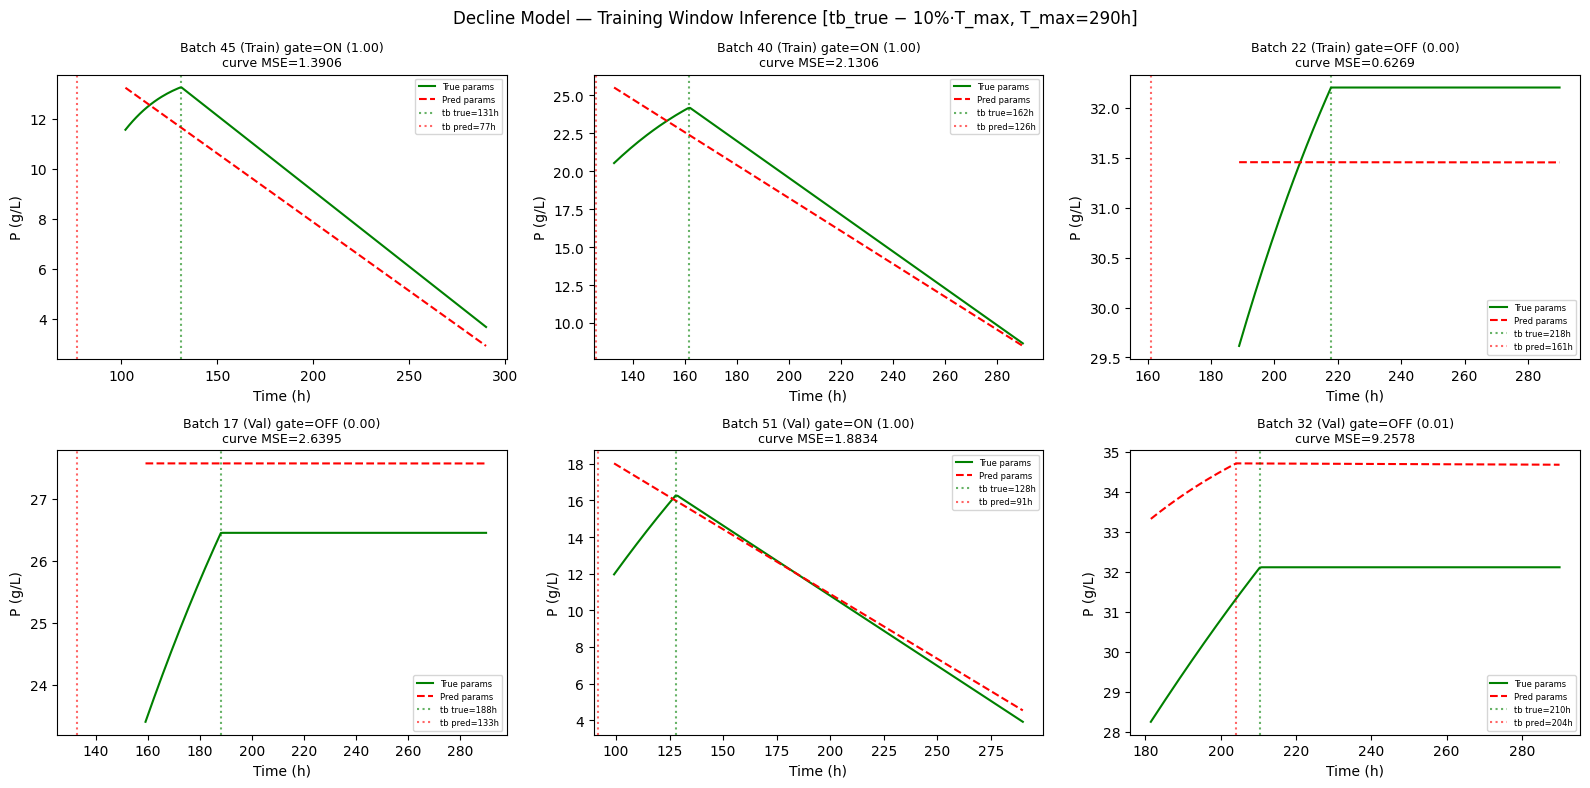

In [10]:
# --- Decline Model: Training-Window Inference (reproducing decline_loss path) ---
timing_m = composite.timing_model.to(device).eval()
growth_m = composite.growth_model.to(device).eval()
decline_m = composite.decline_model.to(device).eval()
T_max_val = decline_m.head.T_max
MARGIN_FRAC = 0.1

train_ds = loaders["train_dataset"]
val_ds = loaders["val_dataset"]

# Pick 3 unique batch IDs from train + 3 from val
train_bids = list(dict.fromkeys(s["batch_id"] for s in train_ds.samples))[:3]
val_bids = list(dict.fromkeys(s["batch_id"] for s in val_ds.samples))[:3]

fig, axes = plt.subplots(2, 3, figsize=(16, 8))

items = (
    [(b, "Train", train_ds) for b in train_bids]
    + [(b, "Val", val_ds) for b in val_bids]
)

for ax, (bid, split_name, ds) in zip(axes.flat, items):
    idx = next(i for i, s in enumerate(ds.samples) if s["batch_id"] == bid)
    sample = ds[idx]
    x_i = sample["x"].unsqueeze(0).to(device)
    params_true = sample["params_fitted"]  # (7,)

    # Reproduce decline_loss inference path (lines 697-699, 308-316)
    with torch.no_grad():
        t_lag_pred = timing_m(x_i)["t_lag"]
        gp = growth_m(x_i)
        t_cutoff_norm_i = (sample["t_cutoff"] / T_max_val).unsqueeze(0).to(device)
        dp = decline_m(x_i, t_cutoff_norm_i)

    # Assemble full predicted params (upstream frozen + decline, soft gate)
    params_pred_np = {
        "K": gp["K"].cpu().item(), "r": gp["r"].cpu().item(),
        "t0": gp["t0"].cpu().item(), "lam": gp["lam"].cpu().item(),
        "t_lag": t_lag_pred.cpu().item(),
        "t_break": dp["t_break"].cpu().item(),
        "slope": dp["slope"].cpu().item() * dp["decline_gate"].cpu().item(),
    }
    params_true_np = {name: params_true[i].item() for i, name in enumerate(PARAM_NAMES)}

    # Training window (decline_loss lines 303-305)
    t_break_true = params_true_np["t_break"]
    t_lo = max(0.0, t_break_true - MARGIN_FRAC * T_max_val)
    t_hi = T_max_val

    # Dense eval grid on exact training window
    t_grid = np.linspace(t_lo, t_hi, 200)
    y_pred = piecelog_numpy(t_grid, **params_pred_np)
    y_true = piecelog_numpy(t_grid, **params_true_np)
    curve_mse = np.mean((y_pred - y_true) ** 2)

    # Plot curves
    ax.plot(t_grid, y_true, "g-", lw=1.5, label="True params")
    ax.plot(t_grid, y_pred, "r--", lw=1.5, label="Pred params")
    ax.axvline(t_break_true, color="green", ls=":", alpha=0.6,
               label=f"tb true={t_break_true:.0f}h")
    ax.axvline(params_pred_np["t_break"], color="red", ls=":", alpha=0.6,
               label=f"tb pred={params_pred_np['t_break']:.0f}h")

    gate_val = dp["decline_gate"].cpu().item()
    gate_str = "ON" if gate_val >= 0.5 else "OFF"
    ax.set_title(f"Batch {bid} ({split_name}) gate={gate_str} ({gate_val:.2f})\n"
                 f"curve MSE={curve_mse:.4f}", fontsize=9)
    ax.set_xlabel("Time (h)")
    ax.set_ylabel("P (g/L)")
    ax.legend(fontsize=6, loc="best")

plt.suptitle(
    f"Decline Model \u2014 Training Window Inference "
    f"[tb_true \u2212 {MARGIN_FRAC:.0%}\u00b7T_max, T_max={T_max_val:.0f}h]",
    fontsize=12,
)
plt.tight_layout()
plt.show()

In [ ]:
ungated_result = retrain_ungated_decline(
    composite,
    fitted_params_df,
    train_loader=loaders["train"],
    val_loader=loaders["val"],
    config={
        "d_model":      8,
        "n_heads":      4,
        "n_layers":     1,
        "d_ff":         8,
        "head_hidden":  4,
        "dropout":      0.1,

        "patch_len":    16,
        "patch_stride": 8,
    },
    n_epochs=200,
    lr=3e-4,
    weight_decay=1e-4,
    patience=100,
    alpha=0.1,
    param_stats=param_stats,
    n_curve_points=40,
    conc_scale=conc_scale,
    device=device,
    verbose=True,
)

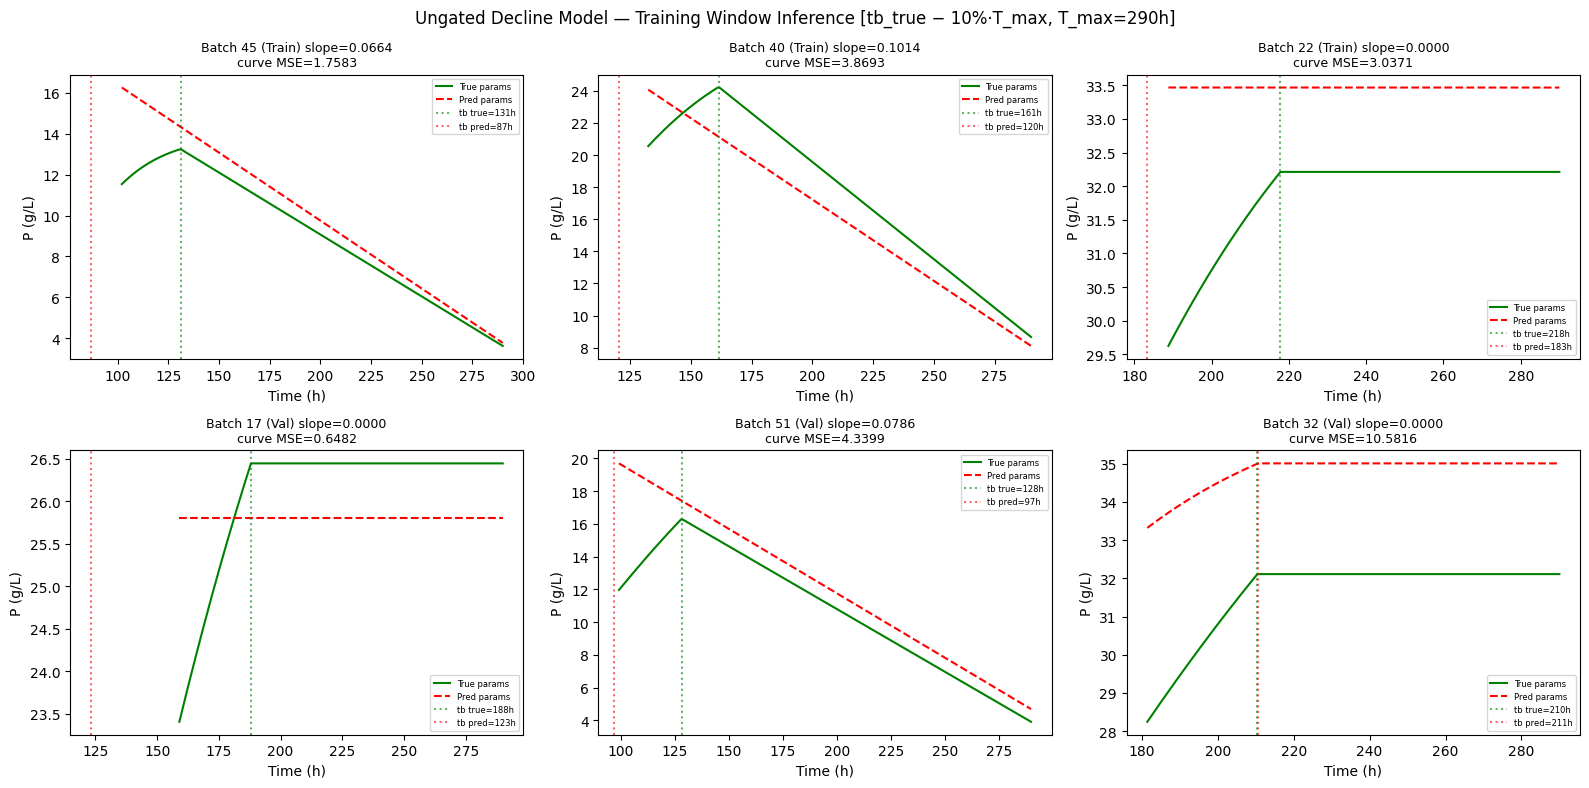

In [16]:
# --- Ungated Decline Model: Training-Window Inference Diagnostic ---
timing_m = composite.timing_model.to(device).eval()
growth_m = composite.growth_model.to(device).eval()
decline_m = composite.decline_model.to(device).eval()
T_max_val = decline_m.head.T_max
MARGIN_FRAC = 0.1

train_ds = loaders["train_dataset"]
val_ds = loaders["val_dataset"]

# Pick 3 unique batch IDs from train + 3 from val
train_bids = list(dict.fromkeys(s["batch_id"] for s in train_ds.samples))[:3]
val_bids = list(dict.fromkeys(s["batch_id"] for s in val_ds.samples))[:3]

fig, axes = plt.subplots(2, 3, figsize=(16, 8))

items = (
    [(b, "Train", train_ds) for b in train_bids]
    + [(b, "Val", val_ds) for b in val_bids]
)

for ax, (bid, split_name, ds) in zip(axes.flat, items):
    idx = next(i for i, s in enumerate(ds.samples) if s["batch_id"] == bid)
    sample = ds[idx]
    x_i = sample["x"].unsqueeze(0).to(device)
    params_true = sample["params_fitted"]  # (7,)

    with torch.no_grad():
        t_lag_pred = timing_m(x_i)["t_lag"]
        gp = growth_m(x_i)
        t_cutoff_norm_i = (sample["t_cutoff"] / T_max_val).unsqueeze(0).to(device)
        dp = decline_m(x_i, t_cutoff_norm_i)

    # Ungated: slope goes directly (no gate multiplication)
    params_pred_np = {
        "K": gp["K"].cpu().item(), "r": gp["r"].cpu().item(),
        "t0": gp["t0"].cpu().item(), "lam": gp["lam"].cpu().item(),
        "t_lag": t_lag_pred.cpu().item(),
        "t_break": dp["t_break"].cpu().item(),
        "slope": dp["slope"].cpu().item(),
    }
    params_true_np = {name: params_true[i].item() for i, name in enumerate(PARAM_NAMES)}

    # Training window
    t_break_true = params_true_np["t_break"]
    t_lo = max(0.0, t_break_true - MARGIN_FRAC * T_max_val)
    t_hi = T_max_val

    t_grid = np.linspace(t_lo, t_hi, 200)
    y_pred = piecelog_numpy(t_grid, **params_pred_np)
    y_true = piecelog_numpy(t_grid, **params_true_np)
    curve_mse = np.mean((y_pred - y_true) ** 2)

    ax.plot(t_grid, y_true, "g-", lw=1.5, label="True params")
    ax.plot(t_grid, y_pred, "r--", lw=1.5, label="Pred params")
    ax.axvline(t_break_true, color="green", ls=":", alpha=0.6,
               label=f"tb true={t_break_true:.0f}h")
    ax.axvline(params_pred_np["t_break"], color="red", ls=":", alpha=0.6,
               label=f"tb pred={params_pred_np['t_break']:.0f}h")

    slope_str = f"slope={dp['slope'].cpu().item():.4f}"
    ax.set_title(f"Batch {bid} ({split_name}) {slope_str}\n"
                 f"curve MSE={curve_mse:.4f}", fontsize=9)
    ax.set_xlabel("Time (h)")
    ax.set_ylabel("P (g/L)")
    ax.legend(fontsize=6, loc="best")

plt.suptitle(
    f"Ungated Decline Model \u2014 Training Window Inference "
    f"[tb_true \u2212 {MARGIN_FRAC:.0%}\u00b7T_max, T_max={T_max_val:.0f}h]",
    fontsize=12,
)
plt.tight_layout()
plt.show()

In [ ]:
results = train_modular_pipeline(
    composite,
    train_loader=loaders["train"],
    val_loader=loaders["val"],
    n_epochs_per_phase=30,
    n_epochs_finetune=50,
    lr=1e-4,
    lr_finetune=1e-4,
    weight_decay=1e-4,
    patience=10,
    alpha=0.01,
    decline_alpha=0.01,
    gate_weight_min=0.01,
    gate_warmup_frac=0.3,
    param_stats=param_stats,
    n_curve_points=10,
    conc_scale=conc_scale,
    finetune=True,
    device=device,
    verbose=True,
)

Phase A-1: Training TimingModel
[Timing] Epoch 10/30 | Loss: 0.0105 | Val: 0.0019
[Timing] Early stopping at epoch 17
Phase A-2: Training GrowthModel
[Growth] Epoch 10/30 | Loss: 0.1894 | Val: 0.1780
[Growth] Epoch 20/30 | Loss: 0.0790 | Val: 0.0617
[Growth] Epoch 30/30 | Loss: 0.0434 | Val: 0.0242
Phase A-3: Training DeclineModel
[Decline] Epoch 10/30 | Loss: 0.4473 | Val: 0.3100
[Decline] Epoch 20/30 | Loss: 0.4347 | Val: 0.2982
[Decline] Epoch 30/30 | Loss: 0.4051 | Val: 0.2775
Phase B: Joint Fine-tuning
[Finetune] Epoch 10/50 | Loss: 0.0776 | Val: 0.0549
[Finetune] Epoch 20/50 | Loss: 0.0752 | Val: 0.0525
[Finetune] Epoch 30/50 | Loss: 0.0699 | Val: 0.0488
[Finetune] Epoch 40/50 | Loss: 0.0621 | Val: 0.0434
[Finetune] Epoch 50/50 | Loss: 0.0485 | Val: 0.0346


### 4.1 Training Curves — Per Sub-Model

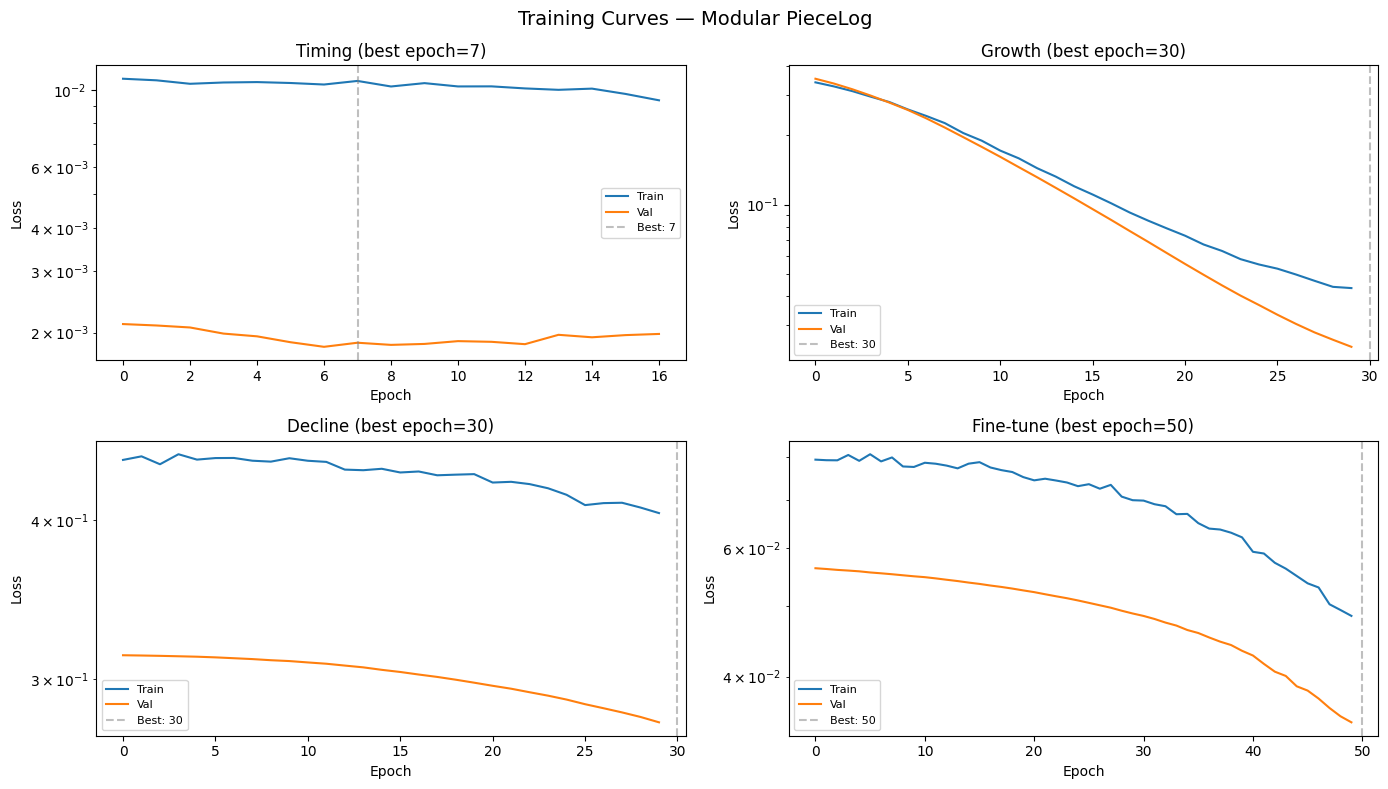

In [15]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

phases = [("timing", "Timing"), ("growth", "Growth"), ("decline", "Decline")]
if "finetune" in results:
    phases.append(("finetune", "Fine-tune"))

for ax, (key, label) in zip(axes.flat, phases):
    h = results[key]["history"]
    ax.semilogy(h["train_loss"], label="Train")
    ax.semilogy(h["val_loss"], label="Val")
    best = results[key]["best_epoch"]
    ax.axvline(best, color="gray", linestyle="--", alpha=0.5, label=f"Best: {best}")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss")
    ax.set_title(f"{label} (best epoch={best})")
    ax.legend(fontsize=8)

# Hide unused subplot if no finetune
if len(phases) < 4:
    axes.flat[3].set_visible(False)

plt.suptitle("Training Curves — Modular PieceLog", fontsize=14)
plt.tight_layout()
plt.show()

## 5. Per Sub-Model Diagnostics

### 5.1 Parameter Scatter — Predicted vs Fitted

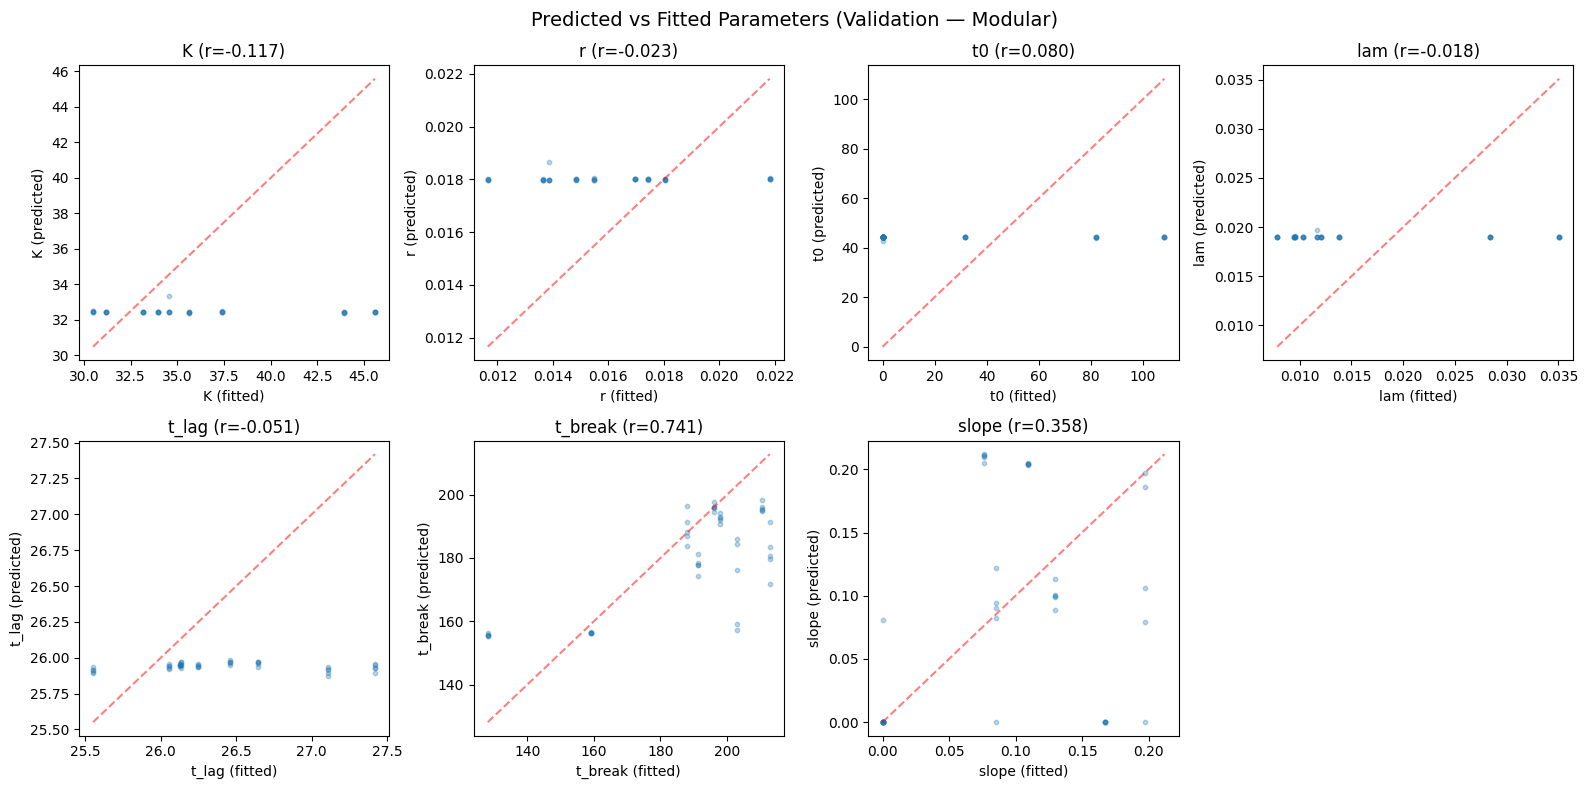

In [16]:
composite.eval()
composite = composite.to(device)

all_params_pred = {p: [] for p in PARAM_NAMES}
all_params_true = {p: [] for p in PARAM_NAMES}

with torch.no_grad():
    for batch in loaders["val"]:
        x = batch["x"].to(device)
        params_pred = composite.get_parameters(x, hard_gate=True)
        params_true = batch["params_fitted"]

        for i, name in enumerate(PARAM_NAMES):
            all_params_pred[name].append(params_pred[name].cpu().numpy())
            all_params_true[name].append(params_true[:, i].numpy())

for name in PARAM_NAMES:
    all_params_pred[name] = np.concatenate(all_params_pred[name])
    all_params_true[name] = np.concatenate(all_params_true[name])

fig, axes = plt.subplots(2, 4, figsize=(16, 8))

for i, name in enumerate(PARAM_NAMES):
    ax = axes.flat[i]
    ax.scatter(all_params_true[name], all_params_pred[name], alpha=0.3, s=10)
    lims = [
        min(all_params_true[name].min(), all_params_pred[name].min()),
        max(all_params_true[name].max(), all_params_pred[name].max()),
    ]
    ax.plot(lims, lims, "r--", alpha=0.5)
    corr = np.corrcoef(all_params_true[name], all_params_pred[name])[0, 1]
    ax.set_xlabel(f"{name} (fitted)")
    ax.set_ylabel(f"{name} (predicted)")
    ax.set_title(f"{name} (r={corr:.3f})")

axes.flat[7].set_visible(False)
plt.suptitle("Predicted vs Fitted Parameters (Validation — Modular)", fontsize=14)
plt.tight_layout()
plt.show()

### 5.2 Decline Gate — Confusion Matrix

In [ ]:
# Collect gate predictions vs targets
gate_preds = []
gate_targets = []
GATE_THRESHOLD = 0.01

composite.eval()
with torch.no_grad():
    for batch in loaders["val"]:
        x = batch["x"].to(device)
        t_cutoff_norm = (batch["t_cutoff"] / composite.decline_model.head.T_max).to(device)
        decline_out = composite.decline_model(x, t_cutoff_norm)
        gate_preds.append(decline_out["decline_gate"].cpu().numpy())
        slope_true = batch["params_fitted"][:, 6].numpy()
        gate_targets.append((slope_true > GATE_THRESHOLD).astype(float))

gate_preds = np.concatenate(gate_preds)
gate_targets = np.concatenate(gate_targets)
gate_binary = (gate_preds >= 0.5).astype(float)

# Confusion matrix
tp = ((gate_binary == 1) & (gate_targets == 1)).sum()
tn = ((gate_binary == 0) & (gate_targets == 0)).sum()
fp = ((gate_binary == 1) & (gate_targets == 0)).sum()
fn = ((gate_binary == 0) & (gate_targets == 1)).sum()

print("Decline Gate Confusion Matrix (Val):")
print(f"  TP={tp}  FP={fp}")
print(f"  FN={fn}  TN={tn}")
accuracy = (tp + tn) / (tp + tn + fp + fn)
print(f"  Accuracy: {accuracy:.3f}")
print(f"  Gate=1 fraction (pred): {gate_binary.mean():.3f}")
print(f"  Gate=1 fraction (true): {gate_targets.mean():.3f}")

## 6. Final Evaluation — MAE / RMSE

In [18]:
import torch.nn as nn

criterion = nn.MSELoss()
composite.eval()
composite = composite.to(device)

print("=" * 55)
print("Modular PieceLog Results (hard gate)")
print("=" * 55)

for split_name, loader in [("Train", loaders["train"]), ("Val", loaders["val"]), ("Target", loaders["target"])]:
    all_preds = []
    all_targets = []
    with torch.no_grad():
        for batch in loader:
            x = batch["x"].to(device)
            t_predict = batch["t_predict"].to(device)
            y_conc = batch["y_conc"]
            P_pred = composite(x, t_predict, hard_gate=True)
            all_preds.append(P_pred.cpu().numpy())
            all_targets.append(y_conc.numpy())

    all_preds = np.concatenate(all_preds)
    all_targets = np.concatenate(all_targets)
    mae = np.mean(np.abs(all_preds - all_targets))
    rmse = np.sqrt(np.mean((all_preds - all_targets) ** 2))
    print(f"  {split_name:>7s} | MAE: {mae:.3f} | RMSE: {rmse:.3f}")

print("=" * 55)

Modular PieceLog Results (hard gate)
    Train | MAE: 3.323 | RMSE: 4.147
      Val | MAE: 3.509 | RMSE: 4.845
   Target | MAE: 2.296 | RMSE: 2.828


## 7. Curve Visualizations

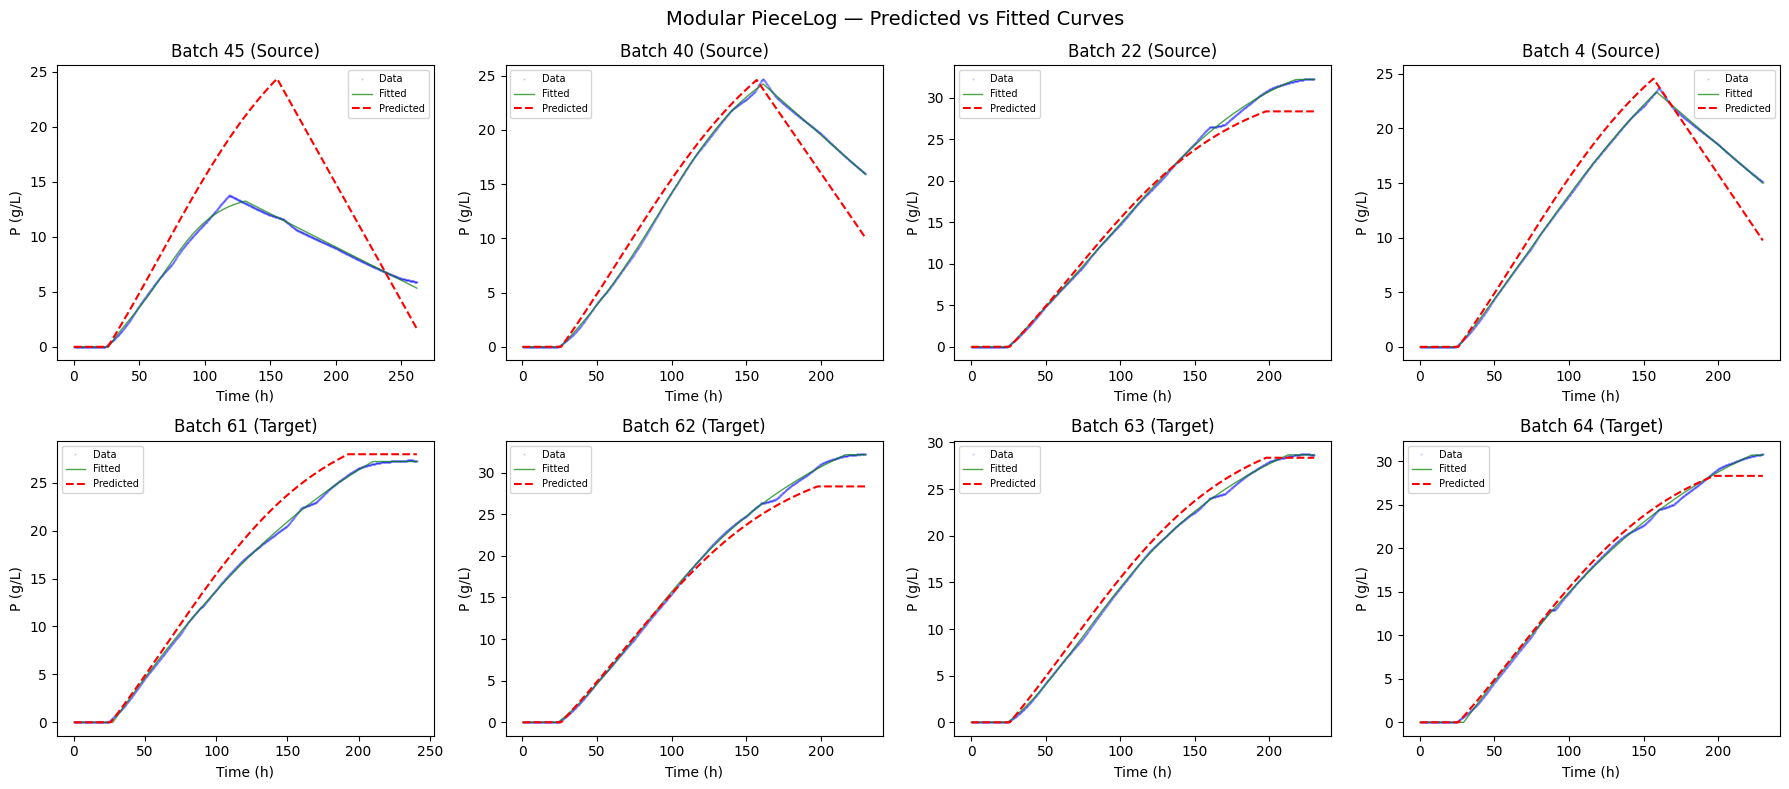

In [19]:
# Show 8 batches: 4 source + 4 target
train_ds = loaders["train_dataset"]
target_ds = loaders["target_dataset"]

train_bids = list(dict.fromkeys(s["batch_id"] for s in train_ds.samples))[:4]
target_bids = list(dict.fromkeys(s["batch_id"] for s in target_ds.samples))[:4]
plot_bids = train_bids + target_bids

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
composite.eval()

for ax, bid in zip(axes.flat, plot_bids):
    df = batches[bid]
    t = df["time"].values
    y_actual = df["P"].values

    # Find sample
    ds = train_ds if bid in [s["batch_id"] for s in train_ds.samples] else target_ds
    sample_idx = next((i for i, s in enumerate(ds.samples) if s["batch_id"] == bid), None)
    if sample_idx is None:
        ax.set_title(f"Batch {bid} — no sample")
        continue

    sample = ds[sample_idx]
    x_input = sample["x"].unsqueeze(0).to(device)

    with torch.no_grad():
        params_pred = composite.get_parameters(x_input, hard_gate=True)
        params_np = {k: v.cpu().item() for k, v in params_pred.items()}

    y_pred_curve = piecelog_numpy(t, **params_np)

    # Fitted curve
    row = fitted_params_df[fitted_params_df["batch_id"] == bid].iloc[0]
    y_fitted_curve = piecelog_numpy(t, *[row[p] for p in PARAM_NAMES])

    ax.plot(t, y_actual, "b.", alpha=0.2, markersize=1, label="Data")
    ax.plot(t, y_fitted_curve, "g-", linewidth=1, alpha=0.7, label="Fitted")
    ax.plot(t, y_pred_curve, "r--", linewidth=1.5, label="Predicted")

    domain = "Source" if bid in source_ids else "Target"
    ax.set_title(f"Batch {bid} ({domain})")
    ax.set_xlabel("Time (h)")
    ax.set_ylabel("P (g/L)")
    ax.legend(fontsize=7)

plt.suptitle("Modular PieceLog — Predicted vs Fitted Curves", fontsize=14)
plt.tight_layout()
plt.show()